# Notebook 1 — Z-Score Based Anomaly Detection

## Objective
This notebook builds a first baseline method for anomaly detection
using the z-score. We generate synthetic medical-like data, inject
artificial anomalies, and detect them using a simple statistical criterion.

## Mathematical Foundation
A z-score measures how far an observation is from the mean,
in units of standard deviation:

Z = (x - μ) / σ

An observation is flagged as anomalous if |Z| > threshold.
We will use a threshold of 3, which corresponds to approximately
99.7% of a normal distribution.

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Generate synthetic normal data
# Simulating a physiological measurement (e.g. heart rate in bpm)

n_patients = 200        # number of observations
mu = 70                 # mean heart rate (bpm)
sigma = 5               # standard deviation

# Generate normal data
data = np.random.normal(loc=mu, scale=sigma, size=n_patients)

print(f"Generated {n_patients} observations")
print(f"Mean: {data.mean():.2f}")
print(f"Standard deviation: {data.std():.2f}")
print(f"Min: {data.min():.2f} | Max: {data.max():.2f}")

Generated 200 observations
Mean: 69.80
Standard deviation: 4.64
Min: 56.90 | Max: 83.60


In [5]:
# Inject artificial anomalies
n_anomalies = 10        # number of anomalies to inject

# Generate anomalous values far from the mean
low_anomalies = np.random.normal(40, 2, 5)    # abnormally low (5 values)
high_anomalies = np.random.normal(110, 2, 5)  # abnormally high (5 values)

# Combine both types of anomalies
anomalies = np.concatenate([low_anomalies, high_anomalies])

# Combine normal data and anomalies
data_with_anomalies = np.concatenate([data, anomalies])

print(f"Total observations: {len(data_with_anomalies)}")
print(f"Normal points: {n_patients}")
print(f"Injected anomalies: {n_anomalies}")
print(f"Anomaly values: {anomalies.round(2)}")

Total observations: 210
Normal points: 200
Injected anomalies: 10
Anomaly values: [ 44.63  36.27  41.37  36.77  39.06 112.18 110.13 107.84 108.57 111.36]


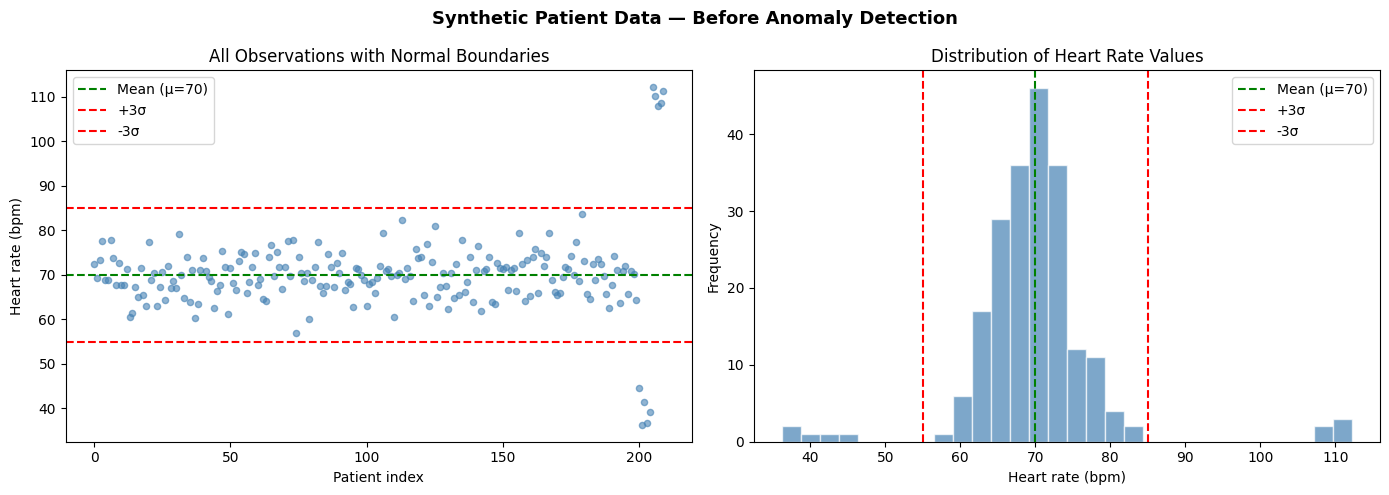

Figure saved.


In [6]:
# Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — All data points
axes[0].scatter(range(len(data_with_anomalies)), data_with_anomalies,
                color='steelblue', alpha=0.6, s=20)
axes[0].axhline(mu, color='green', linestyle='--', label=f'Mean (μ={mu})')
axes[0].axhline(mu + 3*sigma, color='red', linestyle='--', label='+3σ')
axes[0].axhline(mu - 3*sigma, color='red', linestyle='--', label='-3σ')
axes[0].set_title('All Observations with Normal Boundaries')
axes[0].set_xlabel('Patient index')
axes[0].set_ylabel('Heart rate (bpm)')
axes[0].legend()

# Plot 2 — Histogram
axes[1].hist(data_with_anomalies, bins=30, color='steelblue',
             edgecolor='white', alpha=0.7)
axes[1].axvline(mu, color='green', linestyle='--', label=f'Mean (μ={mu})')
axes[1].axvline(mu + 3*sigma, color='red', linestyle='--', label='+3σ')
axes[1].axvline(mu - 3*sigma, color='red', linestyle='--', label='-3σ')
axes[1].set_title('Distribution of Heart Rate Values')
axes[1].set_xlabel('Heart rate (bpm)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Synthetic Patient Data — Before Anomaly Detection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved.")

In [7]:
# Compute z-scores
mean = data_with_anomalies.mean()
std = data_with_anomalies.std()

z_scores = (data_with_anomalies - mean) / std

print(f"Mean used: {mean:.2f}")
print(f"Std used:  {std:.2f}")
print(f"\nMin z-score: {z_scores.min():.2f}")
print(f"Max z-score: {z_scores.max():.2f}")

Mean used: 70.04
Std used:  9.00

Min z-score: -3.75
Max z-score: 4.68


In [8]:
# Flag anomalies using z-score threshold
threshold = 3

anomaly_mask = np.abs(z_scores) > threshold

n_detected = anomaly_mask.sum()

print(f"Threshold: |Z| > {threshold}")
print(f"Total anomalies detected: {n_detected}")
print(f"\nIndices of detected anomalies: {np.where(anomaly_mask)[0]}")
print(f"Values detected: {data_with_anomalies[anomaly_mask].round(2)}")
print(f"Z-scores of detected points: {z_scores[anomaly_mask].round(2)}")

Threshold: |Z| > 3
Total anomalies detected: 9

Indices of detected anomalies: [201 202 203 204 205 206 207 208 209]
Values detected: [ 36.27  41.37  36.77  39.06 112.18 110.13 107.84 108.57 111.36]
Z-scores of detected points: [-3.75 -3.19 -3.7  -3.44  4.68  4.46  4.2   4.28  4.59]


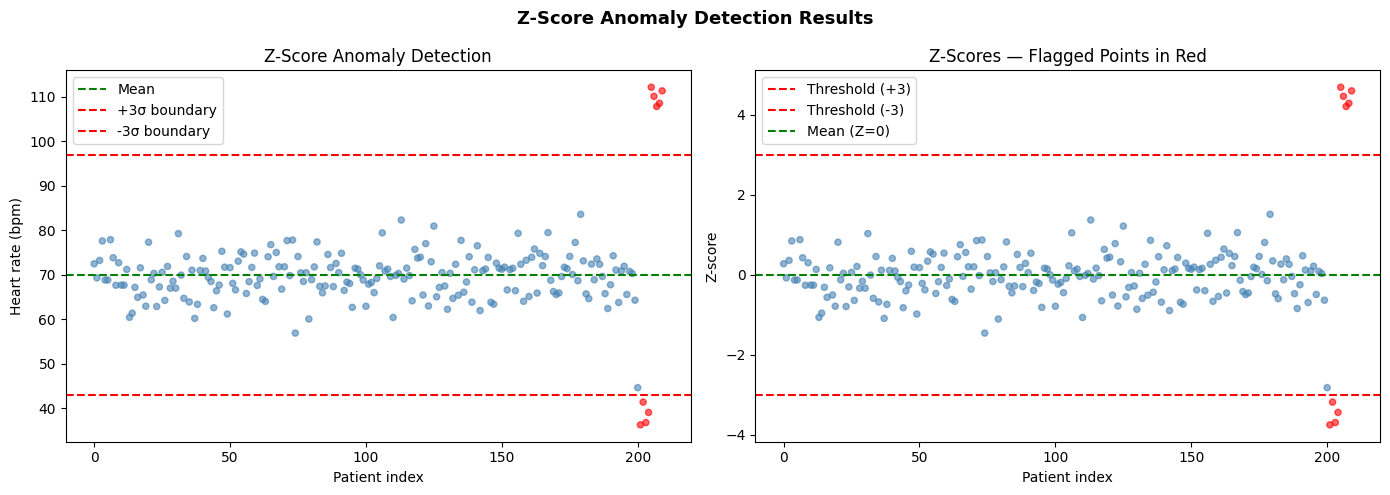

Detection summary: 9 anomalies flagged out of 210 observations.


In [9]:
# Visualize anomaly detection results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colors: red for detected anomalies, blue for normal
colors = ['red' if flag else 'steelblue' for flag in anomaly_mask]

# Plot 1 — Scatter with flagged anomalies
axes[0].scatter(range(len(data_with_anomalies)), data_with_anomalies,
                c=colors, alpha=0.6, s=20)
axes[0].axhline(mean, color='green', linestyle='--', label=f'Mean')
axes[0].axhline(mean + threshold*std, color='red',
                linestyle='--', label=f'+{threshold}σ boundary')
axes[0].axhline(mean - threshold*std, color='red',
                linestyle='--', label=f'-{threshold}σ boundary')
axes[0].set_title('Z-Score Anomaly Detection')
axes[0].set_xlabel('Patient index')
axes[0].set_ylabel('Heart rate (bpm)')
axes[0].legend()

# Plot 2 — Z-score plot
axes[1].scatter(range(len(z_scores)), z_scores,
                c=colors, alpha=0.6, s=20)
axes[1].axhline(threshold, color='red', linestyle='--',
                label=f'Threshold (+{threshold})')
axes[1].axhline(-threshold, color='red', linestyle='--',
                label=f'Threshold (-{threshold})')
axes[1].axhline(0, color='green', linestyle='--', label='Mean (Z=0)')
axes[1].set_title('Z-Scores — Flagged Points in Red')
axes[1].set_xlabel('Patient index')
axes[1].set_ylabel('Z-score')
axes[1].legend()

plt.suptitle('Z-Score Anomaly Detection Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig02_zscore_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Detection summary: {n_detected} anomalies flagged out of {len(data_with_anomalies)} observations.")

## Results and Interpretation

### What we built
We generated 200 synthetic observations drawn from a normal
distribution N(70, 25) simulating patient heart rates, then
injected 10 artificial anomalies (5 abnormally low, 5 abnormally high).

### What the z-score detected
The method flagged 9 out of 10 injected anomalies using a threshold
of |Z| > 3. One anomaly (value ≈ 44.63 bpm) was missed.

### Why one was missed — a key observation
The missed anomaly had a z-score of -2.82, just below the threshold.
This happened because the anomalies themselves inflated the standard
deviation from 5 (the true value) to 9. A larger standard deviation
makes the boundaries wider, reducing sensitivity.

This is a fundamental limitation of the classical z-score:
- It uses the mean and standard deviation
- Both are sensitive to the very outliers we are trying to detect
- This is called a lack of robustness

### What comes next
Notebook 2 will address this limitation using the Median Absolute
Deviation (MAD), a robust alternative that is not distorted by anomalies.